# 05 — Deadline Lag Before and After Newsfeed: Boxplot

## What this notebook does

Visualizes the results of an A/B test — comparing how early or late
students submitted their work relative to deadlines, before and after
the newsfeed feature was introduced.

## Data

- **Source:** `ab-test.csv`
- **Columns:** `group` (test / control), `time` (before / after), `diff` (lag in hours relative to deadline)
- **Total records:** 150

## Key steps

1. Load the A/B test dataset from CSV
2. Split into 4 groups: `test/after`, `test/before`, `control/after`, `control/before`
3. Plot two side-by-side boxplots — one for "after", one for "before"
4. Each boxplot compares control vs test group

## Result

Two boxplots showing the distribution of deadline lags for each group.
Allows to visually assess whether the newsfeed had an impact on how
timely students submitted their work — whether the test group started
committing earlier after the feature was introduced.

## Tools

`pandas` · `matplotlib`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/ab-test.csv')
print(len(df))

44


In [2]:
test_after = df[(df['group'] == 'test') & (df['time'] == 'after')]
test_before = df[(df['group'] == 'test') & (df['time'] == 'before')]
control_after = df[(df['group'] == 'control') & (df['time'] == 'after')]
control_before = df[(df['group'] == 'control') & (df['time'] == 'before')]
print(control_before)
print(len(control_before + test_before))


        uid   diff    time    group
15  user_12 -103.0  before  control
17  user_13  -15.5  before  control
19  user_15   -3.0  before  control
21  user_16 -153.0  before  control
23   user_2 -202.0  before  control
25  user_20  -16.0  before  control
27  user_22 -156.0  before  control
29  user_24  -75.0  before  control
31  user_26  -40.0  before  control
33  user_27   -3.5  before  control
35  user_29 -176.5  before  control
37  user_31  -95.0  before  control
39   user_4 -228.0  before  control
41   user_6  -16.5  before  control
43   user_8 -187.5  before  control
22


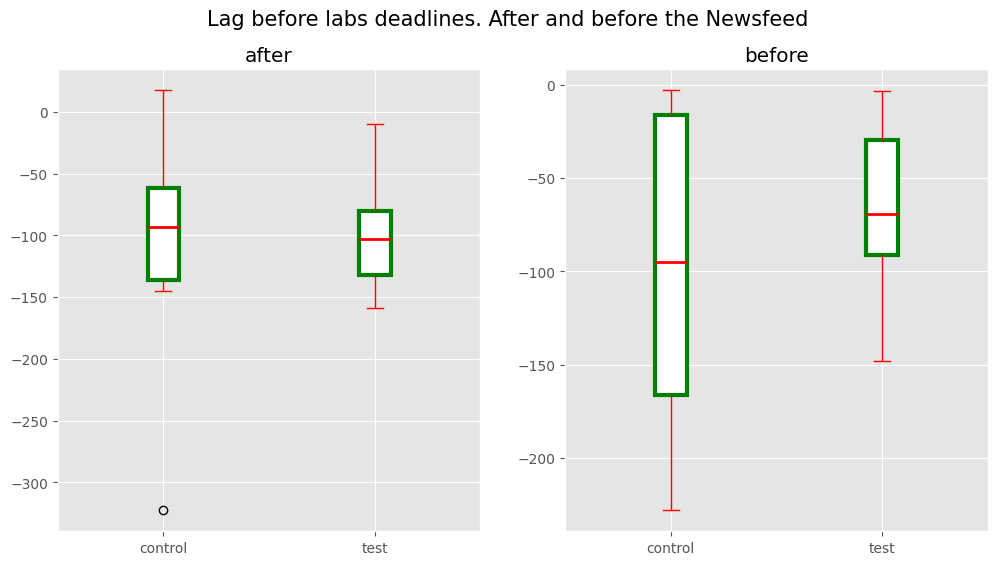

In [3]:
plt.style.use('ggplot')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

bp1 = ax1.boxplot([control_after['diff'], test_after['diff']],
                  patch_artist=True,
                  medianprops=dict(color='red', linewidth=2),
                  boxprops=dict(color='green', linewidth=3, facecolor='white'),
                  whiskerprops=dict(color='red'),
                  capprops=dict(color='red'))
ax1.set_title('after')
ax1.set_xticklabels(['control', 'test'])

bp2 = ax2.boxplot([control_before['diff'], test_before['diff']],
                  patch_artist=True,
                  medianprops=dict(color='red', linewidth=2),
                  boxprops=dict(color='green', linewidth=3, facecolor='white'),
                  whiskerprops=dict(color='red'),
                  capprops=dict(color='red'))
ax2.set_title('before')
ax2.set_xticklabels(['control', 'test'])

fig.suptitle('Lag before labs deadlines. After and before the Newsfeed', fontsize=15)
plt.show()

150